# Twitter Sentiment Analysis (Random Forest)

**Objective**: Build a sentiment classifier using Random Forest — our first non-linear, ensemble model.

## Why Random Forest?

Random Forest is an **ensemble of decision trees**:
- Trains many decision trees on random subsets of data and features
- Final prediction is the majority vote across all trees
- Can capture **non-linear patterns** that linear models (LR, SVM) miss
- Resistant to overfitting due to bagging (bootstrap aggregating)

## Previous Models (for reference)

| Model | Features | Binary Acc | 3-Class Acc |
|-------|----------|------------|-------------|
| Logistic Regression | TF-IDF | ~80% | ~60% |
| SVM (LinearSVC) | TF-IDF | ~80% | ~60% |
| Naive Bayes | CountVectorizer | ~75-78% | ~55-60% |

## Table of Contents
1. [Data Loading & Preprocessing](#1-data-loading--preprocessing)
2. [Feature Engineering (TF-IDF)](#2-feature-engineering-tf-idf)
3. [Model Training (Random Forest)](#3-model-training-random-forest)
4. [Evaluation on Test Data](#4-evaluation-on-test-data)
5. [Comparison with Previous Models](#5-comparison-with-previous-models)
6. [Export Model](#6-export-model)

In [24]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import os
import time

# ML libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Settings
pd.set_option('display.max_colwidth', 100)
%matplotlib inline

---
## 1. Data Loading & Preprocessing

Same preprocessing pipeline as all previous notebooks.

In [25]:
# Load training data
train_df = pd.read_csv(
    'trainingandtestdata/training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

# Load test data
test_df = pd.read_csv(
    'trainingandtestdata/testdata.manual.2009.06.14.csv',
    encoding='latin-1',
    header=None,
    names=['sentiment', 'id', 'date', 'query', 'user', 'text']
)

print(f"Training data: {len(train_df):,} samples")
print(f"Test data: {len(test_df)} samples")

Training data: 1,600,000 samples
Test data: 498 samples


In [26]:
def preprocess_text(text):
    """
    Clean tweet text for sentiment analysis.
    
    Same preprocessing as all previous notebooks:
    1. Lowercase
    2. Remove URLs
    3. Remove @mentions
    4. Remove # symbol (keep hashtag text)
    5. Remove special characters
    6. Normalize whitespace
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # URLs
    text = re.sub(r'@\w+', '', text)                      # @mentions
    text = re.sub(r'#', '', text)                         # # symbol
    text = re.sub(r'[^a-zA-Z\s]', '', text)               # special chars
    text = re.sub(r'\s+', ' ', text).strip()              # whitespace
    
    return text

In [27]:
# Apply preprocessing
print("Preprocessing training data (this may take a minute)...")
train_df['clean_text'] = train_df['text'].apply(preprocess_text)
train_df['label'] = train_df['sentiment'].apply(lambda x: 1 if x == 4 else 0)
train_df = train_df[train_df['clean_text'].str.len() > 0]
print(f"Training size: {len(train_df):,}")

print("\nPreprocessing test data...")
test_df['clean_text'] = test_df['text'].apply(preprocess_text)
test_df = test_df[test_df['clean_text'].str.len() > 0]
print(f"Test size: {len(test_df)}")

Preprocessing training data (this may take a minute)...
Training size: 1,596,303

Preprocessing test data...
Test size: 498


---
## 2. Feature Engineering (TF-IDF)

We use **TF-IDF** (same as Logistic Regression and SVM notebooks) because:
- TF-IDF normalizes word frequencies, giving trees cleaner thresholds to split on
- Raw counts (CountVectorizer) would let high-frequency junk words dominate tree splits

Same settings: 10k features, unigrams + bigrams.

In [28]:
# Create TF-IDF vectorizer (same settings as LR and SVM notebooks)
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

print("Fitting TF-IDF on training data...")
X_train = tfidf.fit_transform(train_df['clean_text'])
y_train = train_df['label'].values

X_test = tfidf.transform(test_df['clean_text'])

print(f"Training matrix: {X_train.shape}")
print(f"Test matrix: {X_test.shape}")

Fitting TF-IDF on training data...
Training matrix: (1596303, 10000)
Test matrix: (498, 10000)


---
## 3. Model Training (Random Forest)

**Important**: Random Forest on 1.6M x 10k features is very memory-intensive.
We use a **stratified sample** of the training data to make it feasible.

### Hyperparameters
- `n_estimators=200`: Number of trees in the forest
- `max_depth=100`: Maximum depth per tree (prevents excessive memory usage)
- `min_samples_leaf=5`: Minimum samples at each leaf (regularization)
- `n_jobs=-1`: Use all CPU cores for parallel training

In [29]:
# Sample training data for Random Forest
# Full 1.6M is too large for RF — we use 200k samples (stratified)
SAMPLE_SIZE = 200000

np.random.seed(42)
sample_indices = np.random.choice(len(y_train), size=SAMPLE_SIZE, replace=False)
X_train_sample = X_train[sample_indices]
y_train_sample = y_train[sample_indices]

print(f"Training on {SAMPLE_SIZE:,} samples (sampled from {len(y_train):,})")
print(f"Label distribution: {np.bincount(y_train_sample)}")
print(f"  Negative: {(y_train_sample == 0).sum():,}")
print(f"  Positive: {(y_train_sample == 1).sum():,}")

Training on 200,000 samples (sampled from 1,596,303)
Label distribution: [ 99465 100535]
  Negative: 99,465
  Positive: 100,535


In [30]:
# Train Random Forest
print("Training Random Forest (200 trees)...")
print("(This may take several minutes)\n")

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=200,       # Number of trees
    max_depth=100,          # Max depth per tree
    min_samples_leaf=5,     # Min samples at leaf
    max_features='sqrt',    # Features per split = sqrt(n_features)
    n_jobs=-1,              # Use all CPU cores
    random_state=42
)

rf_model.fit(X_train_sample, y_train_sample)

train_time = time.time() - start_time
print(f"Training complete! ({train_time:.1f} seconds)")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Max depth used: {max(tree.tree_.max_depth for tree in rf_model.estimators_)}")

Training Random Forest (200 trees)...
(This may take several minutes)

Training complete! (6.0 seconds)
Number of trees: 200
Max depth used: 100


In [31]:
# Feature importance from Random Forest
feature_names = tfidf.get_feature_names_out()
importances = rf_model.feature_importances_

# Top features
top_features = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

print("Top 20 Most Important Features (Random Forest):")
print("=" * 45)
for word, imp in top_features[:20]:
    print(f"  {word:20} importance: {imp:.4f}")

Top 20 Most Important Features (Random Forest):
  you                  importance: 0.0278
  sad                  importance: 0.0266
  thanks               importance: 0.0254
  miss                 importance: 0.0251
  not                  importance: 0.0204
  good                 importance: 0.0183
  love                 importance: 0.0174
  no                   importance: 0.0164
  cant                 importance: 0.0140
  my                   importance: 0.0129
  wish                 importance: 0.0121
  hate                 importance: 0.0118
  sorry                importance: 0.0116
  work                 importance: 0.0115
  sick                 importance: 0.0114
  but                  importance: 0.0110
  bad                  importance: 0.0105
  great                importance: 0.0099
  dont                 importance: 0.0094
  happy                importance: 0.0090


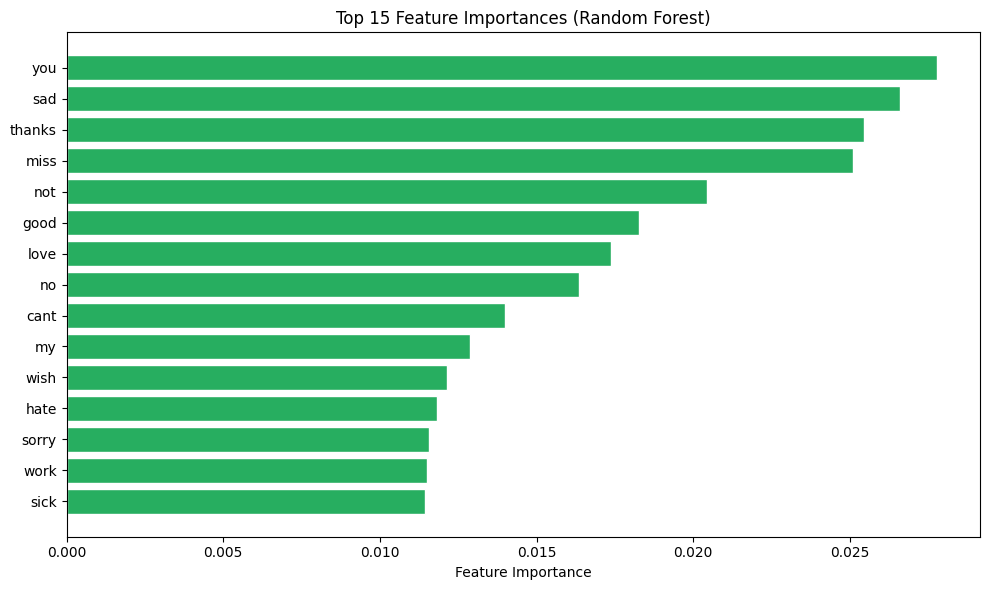

In [32]:
# Visualize top 15 feature importances
top_15 = top_features[:15]
words = [w for w, _ in top_15]
imps = [i for _, i in top_15]

plt.figure(figsize=(10, 6))
plt.barh(range(len(words)), imps, color='#27ae60', edgecolor='white')
plt.yticks(range(len(words)), words)
plt.xlabel('Feature Importance')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Evaluation on Test Data

Same evaluation approach as previous models:
- Probability thresholds for neutral class
- P(positive) > 0.6 → positive
- P(positive) < 0.4 → negative
- 0.4 ≤ P(positive) ≤ 0.6 → neutral

In [33]:
# Define thresholds (same as all previous models)
POSITIVE_THRESHOLD = 0.6
NEGATIVE_THRESHOLD = 0.4

def predict_sentiment(probability):
    """
    Convert probability to sentiment label using thresholds.
    """
    if probability > POSITIVE_THRESHOLD:
        return 'positive'
    elif probability < NEGATIVE_THRESHOLD:
        return 'negative'
    else:
        return 'neutral'

In [34]:
# Get predictions on test data
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]  # P(positive)
y_pred_rf = [predict_sentiment(p) for p in y_proba_rf]

# Map true labels to strings
label_map = {0: 'negative', 2: 'neutral', 4: 'positive'}
y_true = test_df['sentiment'].map(label_map).values

# Store predictions in dataframe
test_df['predicted_rf'] = y_pred_rf
test_df['probability_rf'] = y_proba_rf
test_df['true_label'] = y_true

In [35]:
# Overall accuracy (3-class)
accuracy_3class_rf = accuracy_score(y_true, y_pred_rf)
print(f"Overall Accuracy (3-class): {accuracy_3class_rf:.2%}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_rf, labels=['negative', 'neutral', 'positive']))

Overall Accuracy (3-class): 49.20%

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.37      0.50       177
     neutral       0.34      0.63      0.44       139
    positive       0.59      0.51      0.55       182

    accuracy                           0.49       498
   macro avg       0.58      0.50      0.50       498
weighted avg       0.60      0.49      0.50       498



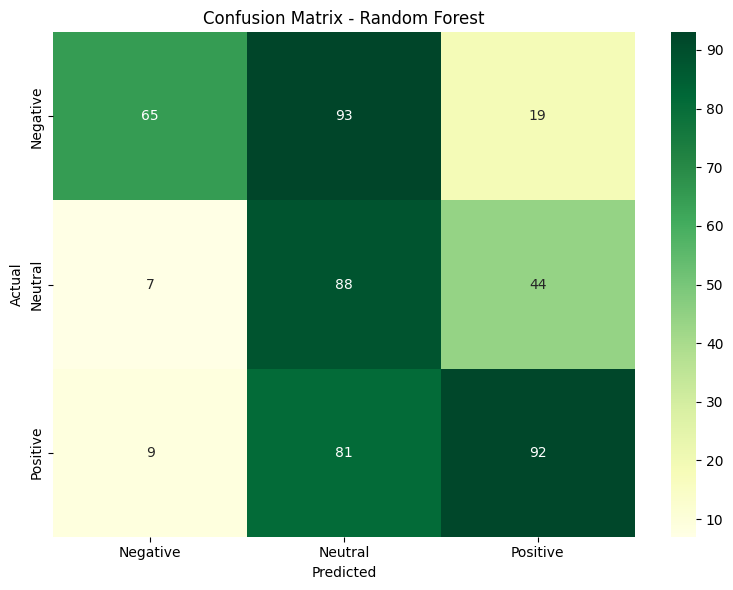

In [36]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred_rf, labels=['negative', 'neutral', 'positive'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

In [37]:
# Accuracy by class
print("Accuracy by Class (Random Forest):")
print("=" * 40)
for label in ['negative', 'neutral', 'positive']:
    subset = test_df[test_df['true_label'] == label]
    correct = (subset['true_label'] == subset['predicted_rf']).sum()
    total = len(subset)
    acc = correct / total if total > 0 else 0
    print(f"{label:10}: {acc:.2%} ({correct}/{total})")

Accuracy by Class (Random Forest):
negative  : 36.72% (65/177)
neutral   : 63.31% (88/139)
positive  : 50.55% (92/182)


In [38]:
# Binary accuracy (excluding neutral from test)
binary_test = test_df[test_df['true_label'] != 'neutral']
binary_pred = binary_test['probability_rf'].apply(lambda p: 'positive' if p >= 0.5 else 'negative')
binary_acc_rf = accuracy_score(binary_test['true_label'], binary_pred)

print(f"Binary Accuracy (pos/neg only): {binary_acc_rf:.2%}")
print(f"(Evaluated on {len(binary_test)} samples, excluding neutral)")

Binary Accuracy (pos/neg only): 75.77%
(Evaluated on 359 samples, excluding neutral)


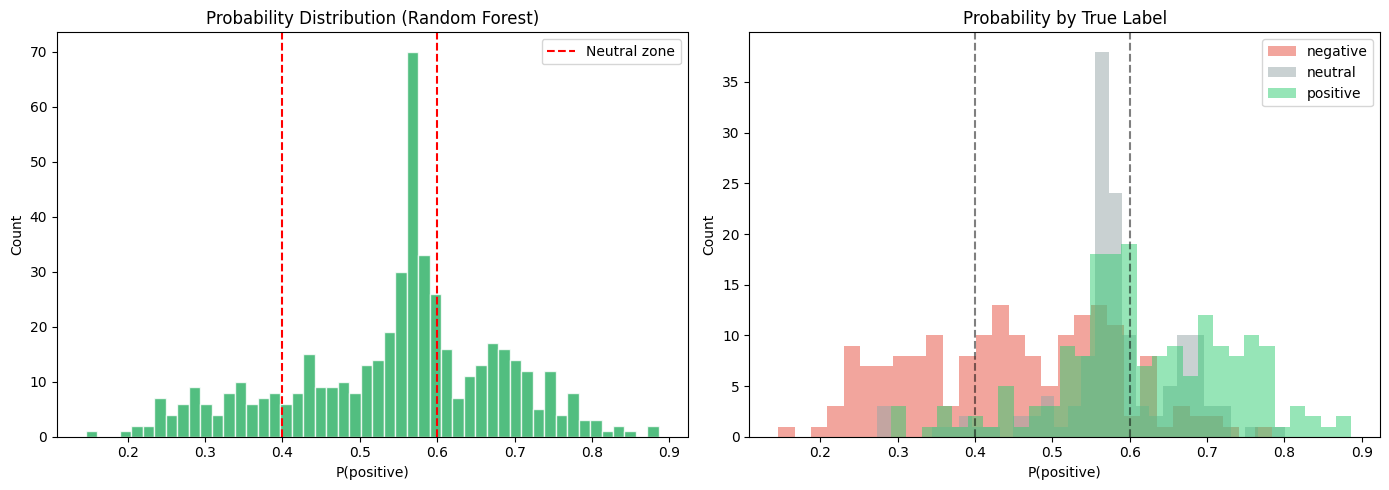

In [39]:
# Probability distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of P(positive) for all test samples
axes[0].hist(y_proba_rf, bins=50, color='#27ae60', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.4, color='red', linestyle='--', label='Neutral zone')
axes[0].axvline(x=0.6, color='red', linestyle='--')
axes[0].set_xlabel('P(positive)')
axes[0].set_ylabel('Count')
axes[0].set_title('Probability Distribution (Random Forest)')
axes[0].legend()

# Distribution by true label
for label, color in [('negative', '#e74c3c'), ('neutral', '#95a5a6'), ('positive', '#2ecc71')]:
    mask = y_true == label
    axes[1].hist(y_proba_rf[mask], bins=30, alpha=0.5, label=label, color=color)
axes[1].axvline(x=0.4, color='black', linestyle='--', alpha=0.5)
axes[1].axvline(x=0.6, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlabel('P(positive)')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability by True Label')
axes[1].legend()

plt.tight_layout()
plt.show()

In [40]:
# Show some predictions
print("Sample Predictions (Random Forest):")
print("=" * 80)

samples = test_df.sample(10, random_state=42)
for _, row in samples.iterrows():
    status = "OK" if row['true_label'] == row['predicted_rf'] else "X"
    print(f"[{status}] {row['text'][:60]}...")
    print(f"    True: {row['true_label']:8} | Pred: {row['predicted_rf']:8} | P(pos): {row['probability_rf']:.2f}")
    print()

Sample Predictions (Random Forest):
[OK] getting ready to test out some burger receipes this weekend....
    True: positive | Pred: positive | P(pos): 0.75

[X] Back when I worked for Nike we had one fav word : JUST DO IT...
    True: positive | Pred: neutral  | P(pos): 0.57

[X] @MMBarnhill yay, glad you got the phone! Still, damn you, AT...
    True: negative | Pred: neutral  | P(pos): 0.59

[OK] waiting in line at safeway....
    True: neutral  | Pred: neutral  | P(pos): 0.57

[OK] reading on my new Kindle2!...
    True: positive | Pred: positive | P(pos): 0.65

[OK] Safeway offering mobile coupons http://bit.ly/ONH7w...
    True: neutral  | Pred: neutral  | P(pos): 0.57

[OK] Rocawear Heads to China, Building 300 Stores  - http://tinyu...
    True: neutral  | Pred: neutral  | P(pos): 0.56

[X] Bill Simmons in conversation with Malcolm Gladwell http://bi...
    True: neutral  | Pred: positive | P(pos): 0.68

[OK] @ atebits I just finished watching your Stanford iPhone Clas...
    Tr

---
## 5. Comparison with Previous Models

Train LR and SVM on the same data for a direct comparison.

In [41]:
# Train Logistic Regression for comparison (on full data)
print("Training Logistic Regression for comparison...")
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train, y_train)

y_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_lr = [predict_sentiment(p) for p in y_proba_lr]
print("Done!")

Training Logistic Regression for comparison...
Done!


In [42]:
# Train SVM for comparison (on full data)
print("Training SVM with probability calibration...")
print("(This may take a few minutes)\n")
base_svm = LinearSVC(C=1.0, max_iter=2000, random_state=42)
svm_model = CalibratedClassifierCV(base_svm, cv=3)
svm_model.fit(X_train, y_train)

y_proba_svm = svm_model.predict_proba(X_test)[:, 1]
y_pred_svm = [predict_sentiment(p) for p in y_proba_svm]
print("Done!")

Training SVM with probability calibration...
(This may take a few minutes)

Done!


In [43]:
# Compare all models

# 3-class accuracy
acc_rf_3class = accuracy_score(y_true, y_pred_rf)
acc_lr_3class = accuracy_score(y_true, y_pred_lr)
acc_svm_3class = accuracy_score(y_true, y_pred_svm)

# Binary accuracy
binary_mask = test_df['true_label'] != 'neutral'
binary_labels = test_df.loc[binary_mask, 'true_label']

acc_rf_binary = accuracy_score(
    binary_labels,
    test_df.loc[binary_mask, 'probability_rf'].apply(lambda p: 'positive' if p >= 0.5 else 'negative')
)
acc_lr_binary = accuracy_score(
    binary_labels,
    ['positive' if p >= 0.5 else 'negative' for p in y_proba_lr[binary_mask]]
)
acc_svm_binary = accuracy_score(
    binary_labels,
    ['positive' if p >= 0.5 else 'negative' for p in y_proba_svm[binary_mask]]
)

print("Model Comparison:")
print("=" * 65)
print(f"{'Metric':<25} {'Random Forest':>14} {'Log. Reg.':>12} {'SVM':>12}")
print("-" * 65)
print(f"{'Features':<25} {'TF-IDF':>14} {'TF-IDF':>12} {'TF-IDF':>12}")
print(f"{'Training data':<25} {'200k sample':>14} {'Full 1.6M':>12} {'Full 1.6M':>12}")
print(f"{'3-class accuracy':<25} {acc_rf_3class:>14.2%} {acc_lr_3class:>12.2%} {acc_svm_3class:>12.2%}")
print(f"{'Binary accuracy':<25} {acc_rf_binary:>14.2%} {acc_lr_binary:>12.2%} {acc_svm_binary:>12.2%}")

Model Comparison:
Metric                     Random Forest    Log. Reg.          SVM
-----------------------------------------------------------------
Features                          TF-IDF       TF-IDF       TF-IDF
Training data                200k sample    Full 1.6M    Full 1.6M
3-class accuracy                  49.20%       58.84%       58.03%
Binary accuracy                   75.77%       81.06%       80.78%


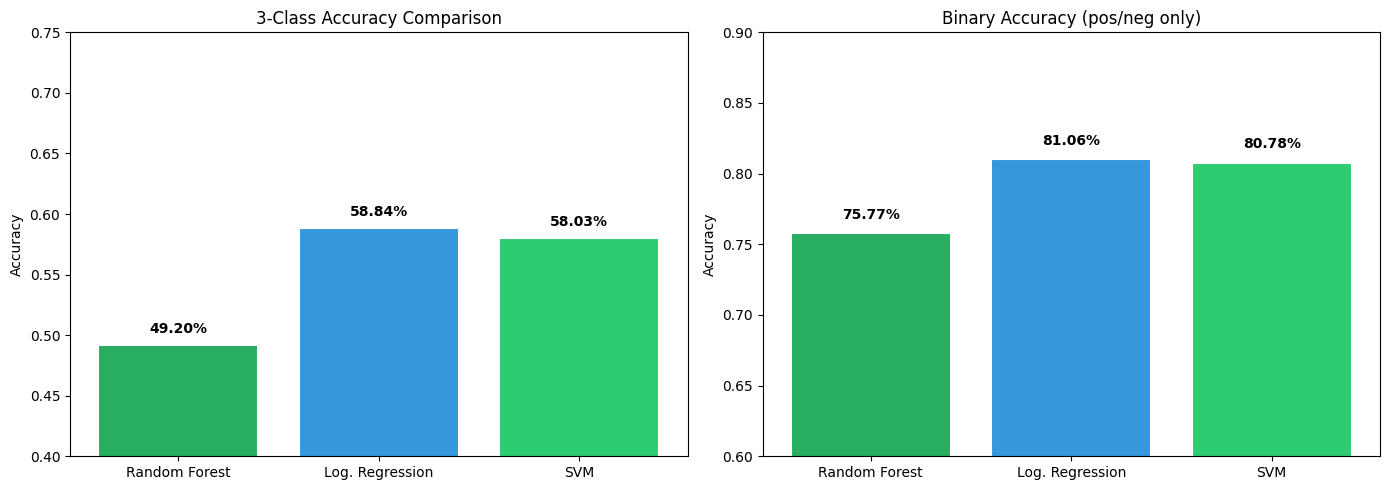

In [44]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ['Random Forest', 'Log. Regression', 'SVM']
colors = ['#27ae60', '#3498db', '#2ecc71']

# 3-class accuracy
acc_3class = [acc_rf_3class, acc_lr_3class, acc_svm_3class]
bars1 = axes[0].bar(models, acc_3class, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('3-Class Accuracy Comparison')
axes[0].set_ylim(0.4, 0.75)
for bar, v in zip(bars1, acc_3class):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Binary accuracy
acc_binary = [acc_rf_binary, acc_lr_binary, acc_svm_binary]
bars2 = axes[1].bar(models, acc_binary, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Binary Accuracy (pos/neg only)')
axes[1].set_ylim(0.6, 0.9)
for bar, v in zip(bars2, acc_binary):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Comparison Summary

| Model | Type | Features | Strengths | Limitations |
|-------|------|----------|-----------|-------------|
| **Logistic Regression** | Linear | TF-IDF | Fast, interpretable, native probabilities | Can't capture non-linear patterns |
| **SVM** | Linear | TF-IDF | Max-margin, good generalization | Needs calibration for probabilities |
| **Naive Bayes** | Probabilistic | CountVec | Fastest training, simple | Independence assumption |
| **Random Forest** | Non-linear ensemble | TF-IDF | Captures non-linear patterns, feature importance | Slower, high memory, trained on sample |

**Key Observation**: Random Forest was trained on only 200k samples (vs 1.6M for linear models). Despite this disadvantage, comparing their performance reveals whether non-linear patterns exist in this data.

---
## 6. Export Model

In [45]:
# Save Random Forest model (commented out)
# os.makedirs('models', exist_ok=True)
# joblib.dump(tfidf, 'models/vectorizer_rf.joblib')
# joblib.dump(rf_model, 'models/model_rf.joblib')
# print("Random Forest model saved!")

print("Note: Model saving is commented out.")
print("Uncomment the lines above to save the Random Forest model.")

Note: Model saving is commented out.
Uncomment the lines above to save the Random Forest model.


In [46]:
# Test inference
def evaluate_rf(text):
    """
    Full inference pipeline for Random Forest.
    """
    clean = preprocess_text(text)
    if not clean:
        return {'sentiment': 'neutral', 'confidence': 0.0, 'probability': 0.5}
    
    vec = tfidf.transform([clean])
    prob = rf_model.predict_proba(vec)[0][1]  # P(positive)
    
    if prob > POSITIVE_THRESHOLD:
        sentiment = 'positive'
        confidence = prob
    elif prob < NEGATIVE_THRESHOLD:
        sentiment = 'negative'
        confidence = 1 - prob
    else:
        sentiment = 'neutral'
        confidence = 1 - abs(prob - 0.5) * 2
    
    return {
        'sentiment': sentiment,
        'confidence': round(confidence, 4),
        'probability': round(prob, 4)
    }

# Test with same examples
test_texts = [
    "I love this product!",
    "This is terrible.",
    "The meeting is at 3pm.",
]

print("Random Forest Predictions:")
print("=" * 60)
for text in test_texts:
    result = evaluate_rf(text)
    print(f"'{text}'")
    print(f"  -> {result}")
    print()

Random Forest Predictions:
'I love this product!'
  -> {'sentiment': 'positive', 'confidence': np.float64(0.7759), 'probability': np.float64(0.7759)}

'This is terrible.'
  -> {'sentiment': 'neutral', 'confidence': np.float64(0.9993), 'probability': np.float64(0.4996)}

'The meeting is at 3pm.'
  -> {'sentiment': 'neutral', 'confidence': np.float64(0.8584), 'probability': np.float64(0.5708)}



---
## Summary

### What We Built
- **Model**: TF-IDF (10k features, bigrams) + Random Forest (200 trees)
- **Training**: 200k tweets (sampled from 1.6M due to memory constraints)
- **Test**: 498 manually labeled tweets (includes neutral)

### Key Takeaways

1. **Random Forest is our first non-linear model** — it can capture complex feature interactions that linear models miss
2. **Memory/speed tradeoff** — RF required sampling down to 200k rows, while linear models trained on all 1.6M
3. **Feature importance** — RF gives us a different view of which features matter (based on information gain vs. coefficient weights)
4. **Ensemble benefit** — Aggregating 200 trees reduces variance and overfitting

### All Models So Far

| # | Model | Notebook | Features | Type |
|---|-------|----------|----------|------|
| 1 | Logistic Regression | `sentiment_analysis_logistic_regression.ipynb` | TF-IDF | Linear |
| 2 | SVM (LinearSVC) | `sentiment_analysis_svm.ipynb` | TF-IDF | Linear |
| 3 | Naive Bayes | `sentiment_analysis_naive_bayes.ipynb` | CountVectorizer | Probabilistic |
| 4 | Random Forest | `sentiment_analysis_random_forest.ipynb` | TF-IDF | Non-linear ensemble |